Total samples: 113

===== Random forest - single band (overall CV results) =====
RMSE = 4.2351
R2   = 0.7006
MAE  = 2.7564
Bias = -0.1749

-- Fold 1 --
RMSE = 6.2549, R2 = 0.5719, MAE = 3.0565, Bias = 0.9855

-- Fold 2 --
RMSE = 3.6148, R2 = 0.5047, MAE = 3.0770, Bias = 0.6551

-- Fold 3 --
RMSE = 6.4287, R2 = 0.7278, MAE = 4.3530, Bias = -2.8765

-- Fold 4 --
RMSE = 6.0484, R2 = 0.7781, MAE = 3.3307, Bias = -1.1742

-- Fold 5 --
RMSE = 2.6390, R2 = 0.2550, MAE = 2.2753, Bias = -1.0567

-- Fold 6 --
RMSE = 2.6598, R2 = 0.5745, MAE = 2.1783, Bias = -0.2734

-- Fold 7 --
RMSE = 2.3573, R2 = 0.4857, MAE = 2.1085, Bias = -0.3221

-- Fold 8 --
RMSE = 2.1469, R2 = 0.2910, MAE = 1.8219, Bias = 0.5445

-- Fold 9 --
RMSE = 3.0956, R2 = 0.5975, MAE = 2.6208, Bias = -0.3936

-- Fold 10 --
RMSE = 3.4442, R2 = 0.8195, MAE = 2.5408, Bias = 2.2270

===== K-fold CV metrics (mean ± std) =====
RMSE: 3.8690 ± 1.6144
R2  : 0.5606 ± 0.1786
MAE : 2.7363 ± 0.7065
Bias: -0.1684 ± 1.3220


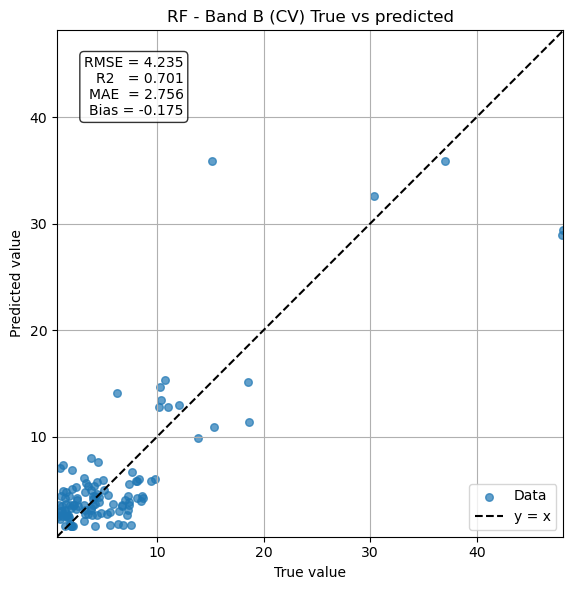

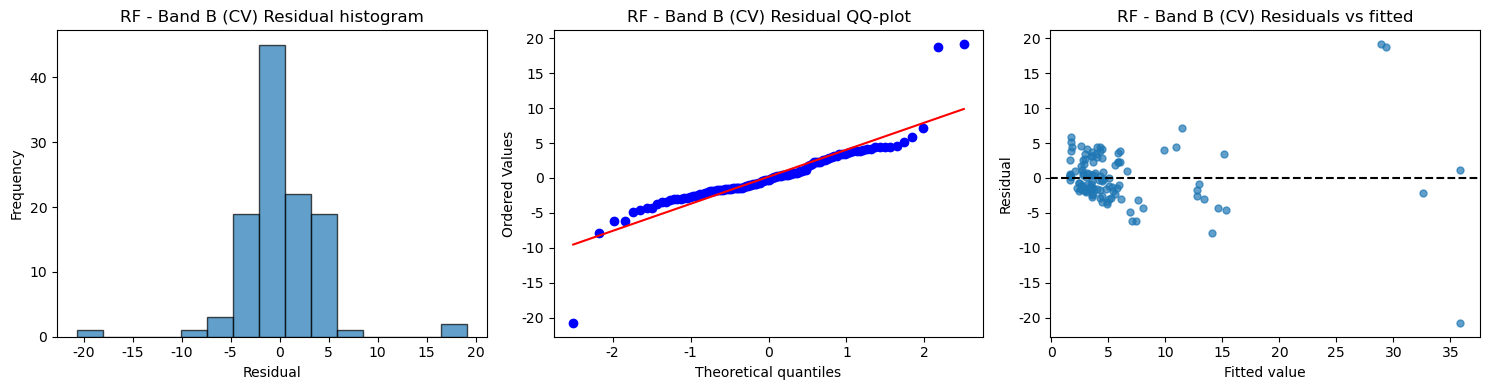


===== Bootstrap 95% confidence intervals (based on CV predictions) =====
RMSE: 4.2351  (95% CI: [2.7694, 5.4963])
R2  : 0.7006  (95% CI: [0.3429, 0.8148])


In [37]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import rcParams
import scipy.stats as stats

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# ====== Basic settings: font & random seed ======
# 如果后面需要在图中写中文，可以换成 SimHei，
# 但现在我们只用英文，保持默认西文字体即可。
rcParams['axes.unicode_minus'] = False
np.random.seed(0)

# ============================================================
# 1. Read single-band data (here: band B)
#    To switch band later, just change excel_path / usecols
# ============================================================
excel_path = r"C:\Users\lirui\Desktop\FL\B.xlsx"

# File has a header in the first row; we skip it and use columns A (X) and B (y)
res = pd.read_excel(
    excel_path,
    header=None,
    skiprows=1,
    usecols="A:B"
).values

X_all = res[:, 0].reshape(-1, 1)   # shape: (n_samples, 1)
y_all = res[:, 1]                  # shape: (n_samples,)

n_samples = X_all.shape[0]
print(f"Total samples: {n_samples}")

# ============================================================
# 2. Define model and K-fold cross validation
#    For BP-R / SVR, just replace the model below
# ============================================================
trees = 12
leaf  = 3

model = RandomForestRegressor(
    n_estimators=trees,
    min_samples_leaf=leaf,
    random_state=0,
    oob_score=False   # we use CV here, no need for OOB
)


# K-fold CV (e.g., 5 folds)
K = 10
cv = KFold(n_splits=K, shuffle=True, random_state=0)

# ============================================================
# 3. Cross-validation: out-of-fold predictions
# ============================================================
y_cv_pred = cross_val_predict(model, X_all, y_all, cv=cv)
resid_cv  = y_all - y_cv_pred

# ============================================================
# 4. Metrics: overall and fold-wise
# ============================================================

def regression_metrics(y_true, y_pred):
    """Return RMSE, R2, MAE, Bias."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    bias = np.mean(y_pred - y_true)   # positive => overestimation
    return rmse, r2, mae, bias

# ---- 4.1 Overall metrics (based on all out-of-fold predictions) ----
rmse_all, r2_all, mae_all, bias_all = regression_metrics(y_all, y_cv_pred)

print("\n===== Random forest - single band (overall CV results) =====")
print(f"RMSE = {rmse_all:.4f}")
print(f"R2   = {r2_all:.4f}")
print(f"MAE  = {mae_all:.4f}")
print(f"Bias = {bias_all:.4f}")

# ---- 4.2 Fold-wise metrics: for tables (mean ± std) ----
rmse_folds = []
r2_folds   = []
mae_folds  = []
bias_folds = []

fold_id = 1
for train_idx, test_idx in cv.split(X_all):
    X_tr, X_te = X_all[train_idx], X_all[test_idx]
    y_tr, y_te = y_all[train_idx], y_all[test_idx]

    m = RandomForestRegressor(
        n_estimators=trees,
        min_samples_leaf=leaf,
        random_state=0
    )
    m.fit(X_tr, y_tr)
    y_te_pred = m.predict(X_te)

    rmse, r2, mae, bias = regression_metrics(y_te, y_te_pred)
    rmse_folds.append(rmse)
    r2_folds.append(r2)
    mae_folds.append(mae)
    bias_folds.append(bias)

    print(f"\n-- Fold {fold_id} --")
    print(f"RMSE = {rmse:.4f}, R2 = {r2:.4f}, MAE = {mae:.4f}, Bias = {bias:.4f}")
    fold_id += 1

print("\n===== K-fold CV metrics (mean ± std) =====")
print(f"RMSE: {np.mean(rmse_folds):.4f} ± {np.std(rmse_folds):.4f}")
print(f"R2  : {np.mean(r2_folds ):.4f} ± {np.std(r2_folds ):.4f}")
print(f"MAE : {np.mean(mae_folds):.4f} ± {np.std(mae_folds):.4f}")
print(f"Bias: {np.mean(bias_folds):.4f} ± {np.std(bias_folds):.4f}")

# ============================================================
# 5. Figure 7-style diagnostics (based on CV predictions)
#    5.1: True vs Predicted scatter, with 1:1 line & in-panel metrics
#    5.2: Residuals vs Fitted (with zero line)
#    5.3: Residual histogram & QQ plot
# ============================================================

def scatter_true_vs_pred(y_true, y_pred, title_prefix=""):
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Scatter points with label
    ax.scatter(y_true, y_pred, s=30, alpha=0.7, label='Data')

    # 1:1 reference line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], '--k', label='y = x')

    # Same axis limits & aspect ratio = 1
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.set_aspect('equal', adjustable='box')

    # Metrics text (top-right, in English, R2 without superscript)
    rmse, r2, mae, bias = regression_metrics(y_true, y_pred)
    text_str = (
        f"RMSE = {rmse:.3f}\n"
        f"R2   = {r2:.3f}\n"
        f"MAE  = {mae:.3f}\n"
        f"Bias = {bias:.3f}"
    )
    ax.text(
        0.25, 0.95, text_str,
        transform=ax.transAxes,
        va='top', ha='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

    ax.set_xlabel('True value')
    ax.set_ylabel('Predicted value')
    ax.set_title(f'{title_prefix}True vs predicted')
    ax.grid(True)

    # Legend at lower right to avoid overlap with metrics text
    ax.legend(loc='lower right')

    plt.tight_layout()
    plt.show()

def residual_diagnostics(y_true, y_pred, title_prefix=""):
    residuals = y_true - y_pred
    fitted    = y_pred

    plt.figure(figsize=(15, 4))

    # (1) Residual histogram
    plt.subplot(1, 3, 1)
    plt.hist(residuals, bins=15, edgecolor='k', alpha=0.7)
    plt.xlabel('Residual')
    plt.ylabel('Frequency')
    plt.title(f'{title_prefix}Residual histogram')

    # (2) QQ plot
    plt.subplot(1, 3, 2)
    stats.probplot(residuals, dist='norm', plot=plt)
    plt.title(f'{title_prefix}Residual QQ-plot')

    # (3) Residuals vs fitted
    plt.subplot(1, 3, 3)
    plt.scatter(fitted, residuals, s=25, alpha=0.7)
    plt.axhline(0, color='k', linestyle='--')
    plt.xlabel('Fitted value')
    plt.ylabel('Residual')
    plt.title(f'{title_prefix}Residuals vs fitted')

    plt.tight_layout()
    plt.show()

# ---- 5.1 & 5.2 & 5.3: based on all-sample CV predictions ----
scatter_true_vs_pred(y_all, y_cv_pred, title_prefix="RF - Band B (CV) ")
residual_diagnostics(y_all, y_cv_pred, title_prefix="RF - Band B (CV) ")

# ============================================================
# 6. Bootstrap confidence intervals (RMSE and R2)
# ============================================================

def bootstrap_ci(y_true, y_pred, metric_func, n_boot=1000, alpha=0.05):
    """
    y_true, y_pred: full-sample vectors
    metric_func: function (y_true_boot, y_pred_boot) -> scalar metric
    return: (lower, upper) CI
    """
    rng = np.random.default_rng(0)
    n  = len(y_true)
    vals = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)  # resample with replacement
        yt_boot = y_true[idx]
        yp_boot = y_pred[idx]
        vals.append(metric_func(yt_boot, yp_boot))

    vals = np.array(vals)
    lower = np.quantile(vals, alpha/2)
    upper = np.quantile(vals, 1 - alpha/2)
    return lower, upper

def rmse_fn(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def r2_fn(y_true, y_pred):
    return r2_score(y_true, y_pred)

rmse_l, rmse_u = bootstrap_ci(y_all, y_cv_pred, rmse_fn, n_boot=1000, alpha=0.05)
r2_l,   r2_u   = bootstrap_ci(y_all, y_cv_pred, r2_fn,   n_boot=1000, alpha=0.05)

print("\n===== Bootstrap 95% confidence intervals (based on CV predictions) =====")
print(f"RMSE: {rmse_all:.4f}  (95% CI: [{rmse_l:.4f}, {rmse_u:.4f}])")
print(f"R2  : {r2_all:.4f}  (95% CI: [{r2_l:.4f}, {r2_u:.4f}])")


Total samples: 113

===== Grid search over RF hyperparameters =====
[TRY] n_estimators=50, min_leaf=1, max_features=None, max_depth=None => mean R2 = 0.3303
[TRY] n_estimators=50, min_leaf=1, max_features=None, max_depth=5 => mean R2 = 0.4396
[TRY] n_estimators=50, min_leaf=1, max_features=None, max_depth=10 => mean R2 = 0.3531
[TRY] n_estimators=50, min_leaf=1, max_features=None, max_depth=20 => mean R2 = 0.3303
[TRY] n_estimators=50, min_leaf=1, max_features=sqrt, max_depth=None => mean R2 = 0.3303
[TRY] n_estimators=50, min_leaf=1, max_features=sqrt, max_depth=5 => mean R2 = 0.4396
[TRY] n_estimators=50, min_leaf=1, max_features=sqrt, max_depth=10 => mean R2 = 0.3531
[TRY] n_estimators=50, min_leaf=1, max_features=sqrt, max_depth=20 => mean R2 = 0.3303
[TRY] n_estimators=50, min_leaf=2, max_features=None, max_depth=None => mean R2 = 0.4496
[TRY] n_estimators=50, min_leaf=2, max_features=None, max_depth=5 => mean R2 = 0.4840
[TRY] n_estimators=50, min_leaf=2, max_features=None, max_d

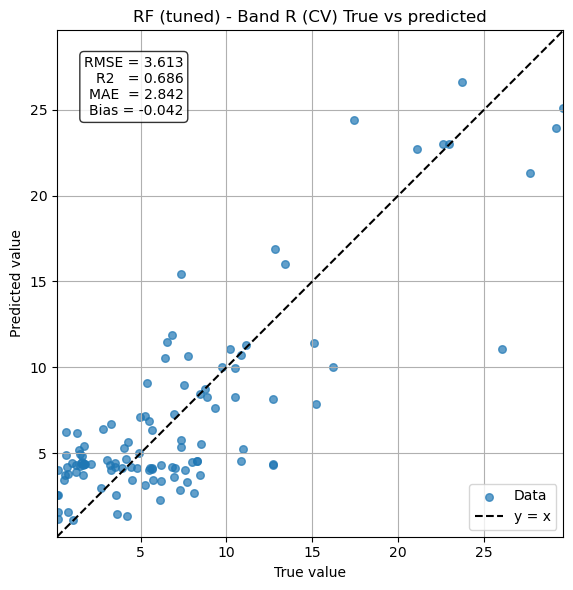

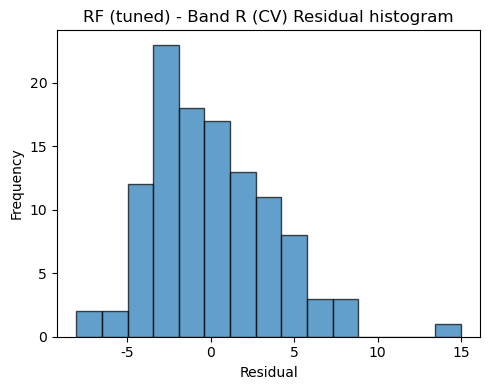

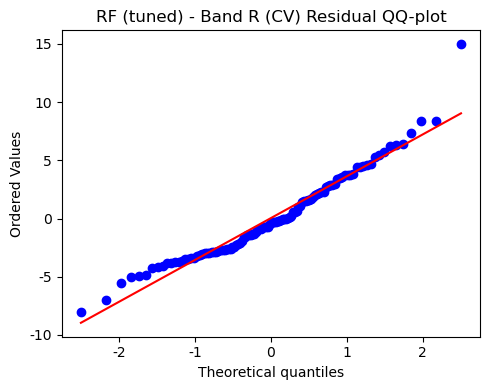

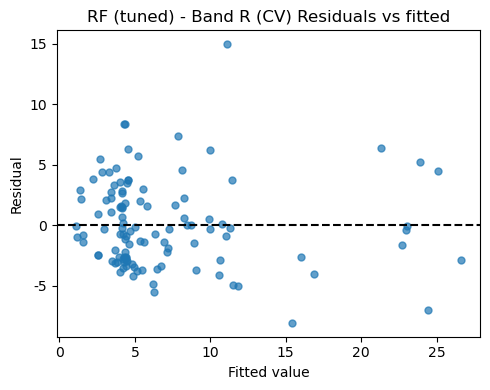


===== Bootstrap 95% confidence intervals (based on CV predictions) =====
RMSE: 3.6131  (95% CI: [3.0402, 4.2758])
R2  : 0.6856  (95% CI: [0.5061, 0.7902])


In [7]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import rcParams
import scipy.stats as stats

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_predict, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# ====== Basic settings: font & random seed ======
rcParams['axes.unicode_minus'] = False
np.random.seed(0)

# ============================================================
# 1. Read single-band data (here: band B)
#    To switch band later, just change excel_path / usecols
# ============================================================
excel_path = r"C:\Users\lirui\Desktop\FL\R.xlsx"

# File has a header in the first row; we skip it and use columns A (X) and B (y)
res = pd.read_excel(
    excel_path,
    header=None,
    skiprows=1,
    usecols="A:B"
).values

X_all = res[:, 0].reshape(-1, 1)   # shape: (n_samples, 1)
y_all = res[:, 1]                  # shape: (n_samples,)

n_samples = X_all.shape[0]
print(f"Total samples: {n_samples}")

# ============================================================
# 2. Define K-fold cross validation
# ============================================================
K = 10
cv = KFold(n_splits=K, shuffle=True, random_state=0)

# ============================================================
# 3. Small grid search for RF hyperparameters (to improve R2)
# ============================================================

param_grid = {
    "n_estimators":    [50, 100, 200, 300],  # number of trees
    "min_samples_leaf": [1, 2, 3, 5],        # minimum samples in leaf
    "max_features":    [None, "sqrt"],       # None => all, "sqrt" => sqrt(d)
    "max_depth":       [None, 5, 10, 20]     # depth limit
}

best_mean_r2 = -np.inf
best_params  = None

print("\n===== Grid search over RF hyperparameters =====")
for n_estimators in param_grid["n_estimators"]:
    for min_leaf in param_grid["min_samples_leaf"]:
        for max_feat in param_grid["max_features"]:
            for max_depth in param_grid["max_depth"]:
                model_tmp = RandomForestRegressor(
                    n_estimators=n_estimators,
                    min_samples_leaf=min_leaf,
                    max_features=max_feat,
                    max_depth=max_depth,
                    random_state=0,
                    oob_score=False
                )
                r2_scores = cross_val_score(
                    model_tmp, X_all, y_all,
                    cv=cv,
                    scoring="r2"
                )
                mean_r2 = r2_scores.mean()
                print(f"[TRY] n_estimators={n_estimators}, "
                      f"min_leaf={min_leaf}, max_features={max_feat}, "
                      f"max_depth={max_depth} => mean R2 = {mean_r2:.4f}")

                if mean_r2 > best_mean_r2:
                    best_mean_r2 = mean_r2
                    best_params  = {
                        "n_estimators": n_estimators,
                        "min_samples_leaf": min_leaf,
                        "max_features": max_feat,
                        "max_depth": max_depth
                    }

print("\n===== Best RF params by CV (R2) =====")
print(best_params)
print(f"Best mean R2 = {best_mean_r2:.4f}")

# ============================================================
# 4. Build final RF model with best_params and get CV predictions
# ============================================================

model = RandomForestRegressor(
    n_estimators    = best_params["n_estimators"],
    min_samples_leaf= best_params["min_samples_leaf"],
    max_features    = best_params["max_features"],
    max_depth       = best_params["max_depth"],
    random_state    = 0,
    oob_score       = False
)

# Cross-validated predictions (out-of-fold)
y_cv_pred = cross_val_predict(model, X_all, y_all, cv=cv)
resid_cv  = y_all - y_cv_pred

# ============================================================
# 5. Metrics: overall and fold-wise
# ============================================================

def regression_metrics(y_true, y_pred):
    """Return RMSE, R2, MAE, Bias."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    bias = np.mean(y_pred - y_true)   # positive => overestimation
    return rmse, r2, mae, bias

# ---- 5.1 Overall metrics (based on all out-of-fold predictions) ----
rmse_all, r2_all, mae_all, bias_all = regression_metrics(y_all, y_cv_pred)

print("\n===== Random forest (tuned) - single band B (overall CV results) =====")
print(f"RMSE = {rmse_all:.4f}")
print(f"R2   = {r2_all:.4f}")
print(f"MAE  = {mae_all:.4f}")
print(f"Bias = {bias_all:.4f}")

# ---- 5.2 Fold-wise metrics: for tables (mean ± std) ----
rmse_folds = []
r2_folds   = []
mae_folds  = []
bias_folds = []

fold_id = 1
for train_idx, test_idx in cv.split(X_all):
    X_tr, X_te = X_all[train_idx], X_all[test_idx]
    y_tr, y_te = y_all[train_idx], y_all[test_idx]

    m = RandomForestRegressor(
        n_estimators    = best_params["n_estimators"],
        min_samples_leaf= best_params["min_samples_leaf"],
        max_features    = best_params["max_features"],
        max_depth       = best_params["max_depth"],
        random_state    = 0,
        oob_score       = False
    )
    m.fit(X_tr, y_tr)
    y_te_pred = m.predict(X_te)

    rmse, r2, mae, bias = regression_metrics(y_te, y_te_pred)
    rmse_folds.append(rmse)
    r2_folds.append(r2)
    mae_folds.append(mae)
    bias_folds.append(bias)

    print(f"\n-- Fold {fold_id} --")
    print(f"RMSE = {rmse:.4f}, R2 = {r2:.4f}, MAE = {mae:.4f}, Bias = {bias:.4f}")
    fold_id += 1

print("\n===== K-fold CV metrics (mean ± std) =====")
print(f"RMSE: {np.mean(rmse_folds):.4f} ± {np.std(rmse_folds):.4f}")
print(f"R2  : {np.mean(r2_folds ):.4f} ± {np.std(r2_folds ):.4f}")
print(f"MAE : {np.mean(mae_folds):.4f} ± {np.std(mae_folds):.4f}")
print(f"Bias: {np.mean(bias_folds):.4f} ± {np.std(bias_folds):.4f}")

# ============================================================
# 6. Figure 7-style diagnostics (based on CV predictions)
#    6.1: True vs Predicted scatter  -> 1 figure
#    6.2: Residual histogram         -> 1 figure
#    6.3: Residual QQ plot           -> 1 figure
#    6.4: Residuals vs Fitted        -> 1 figure
# ============================================================

def scatter_true_vs_pred(y_true, y_pred, title_prefix="", save_prefix=None):
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Scatter points with label
    ax.scatter(y_true, y_pred, s=30, alpha=0.7, label='Data')

    # 1:1 reference line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], '--k', label='y = x')

    # Same axis limits & aspect ratio = 1
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.set_aspect('equal', adjustable='box')

    # Metrics text
    rmse, r2, mae, bias = regression_metrics(y_true, y_pred)
    text_str = (
        f"RMSE = {rmse:.3f}\n"
        f"R2   = {r2:.3f}\n"
        f"MAE  = {mae:.3f}\n"
        f"Bias = {bias:.3f}"
    )
    ax.text(
        0.25, 0.95, text_str,
        transform=ax.transAxes,
        va='top', ha='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

    ax.set_xlabel('True value')
    ax.set_ylabel('Predicted value')
    ax.set_title(f'{title_prefix}True vs predicted')
    ax.grid(True)
    ax.legend(loc='lower right')

    plt.tight_layout()

    # === save ===
    if save_prefix is not None:
        fig.savefig(f"{save_prefix}_scatter.png", dpi=300, bbox_inches="tight")

    plt.show()

def residual_diagnostics(y_true, y_pred, title_prefix="", save_prefix=None):
    residuals = y_true - y_pred
    fitted    = y_pred

    # ===== (1) Residual histogram =====
    fig1, ax1 = plt.subplots(figsize=(5, 4))
    ax1.hist(residuals, bins=15, edgecolor='k', alpha=0.7)
    ax1.set_xlabel('Residual')
    ax1.set_ylabel('Frequency')
    ax1.set_title(f'{title_prefix}Residual histogram')
    plt.tight_layout()
    if save_prefix is not None:
        fig1.savefig(f"{save_prefix}_residual_hist.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ===== (2) QQ plot =====
    fig2, ax2 = plt.subplots(figsize=(5, 4))
    stats.probplot(residuals, dist='norm', plot=ax2)
    ax2.set_title(f'{title_prefix}Residual QQ-plot')
    plt.tight_layout()
    if save_prefix is not None:
        fig2.savefig(f"{save_prefix}_residual_qq.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ===== (3) Residuals vs fitted =====
    fig3, ax3 = plt.subplots(figsize=(5, 4))
    ax3.scatter(fitted, residuals, s=25, alpha=0.7)
    ax3.axhline(0, color='k', linestyle='--')
    ax3.set_xlabel('Fitted value')
    ax3.set_ylabel('Residual')
    ax3.set_title(f'{title_prefix}Residuals vs fitted')
    plt.tight_layout()
    if save_prefix is not None:
        fig3.savefig(f"{save_prefix}_residual_vs_fitted.png", dpi=300, bbox_inches="tight")
    plt.show()

# ---- 6.x: plot diagnostics & save 4 figures ----
# 这里可以改成绝对路径，比如：
# save_prefix = r"C:\Users\lirui\Desktop\FL\RF_BandB_CV"
save_prefix = r"RF_BandR_CV"

scatter_true_vs_pred(
    y_all, y_cv_pred,
    title_prefix="RF (tuned) - Band R (CV) ",
    save_prefix=save_prefix
)

residual_diagnostics(
    y_all, y_cv_pred,
    title_prefix="RF (tuned) - Band R (CV) ",
    save_prefix=save_prefix
)

# ============================================================
# 7. Bootstrap confidence intervals (RMSE and R2)
# ============================================================

def bootstrap_ci(y_true, y_pred, metric_func, n_boot=1000, alpha=0.05):
    rng = np.random.default_rng(0)
    n  = len(y_true)
    vals = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)  # resample with replacement
        yt_boot = y_true[idx]
        yp_boot = y_pred[idx]
        vals.append(metric_func(yt_boot, yp_boot))

    vals = np.array(vals)
    lower = np.quantile(vals, alpha/2)
    upper = np.quantile(vals, 1 - alpha/2)
    return lower, upper

def rmse_fn(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def r2_fn(y_true, y_pred):
    return r2_score(y_true, y_pred)

rmse_l, rmse_u = bootstrap_ci(y_all, y_cv_pred, rmse_fn, n_boot=1000, alpha=0.05)
r2_l,   r2_u   = bootstrap_ci(y_all, y_cv_pred, r2_fn,   n_boot=1000, alpha=0.05)

print("\n===== Bootstrap 95% confidence intervals (based on CV predictions) =====")
print(f"RMSE: {rmse_all:.4f}  (95% CI: [{rmse_l:.4f}, {rmse_u:.4f}])")
print(f"R2  : {r2_all:.4f}  (95% CI: [{r2_l:.4f}, {r2_u:.4f}])")
